# Important differential equations

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
import math

## $y' = ay$

The solution of  $y' = ay$ is $y = C e^{at}$ where $C$ is a constant.

In [4]:
def f(a, c, t):
    y = c * np.exp(a * t)
    return y

In [5]:
# Plot solutions for c in [-1, 1.] and a = .5
m = 21
c = np.linspace(-1., 1., m)
n = 10
t = np.linspace(-1., 1., n)
y = np.zeros((n, m))
for j in range(m):
    y[:, j] = f(.5, c[j], t)

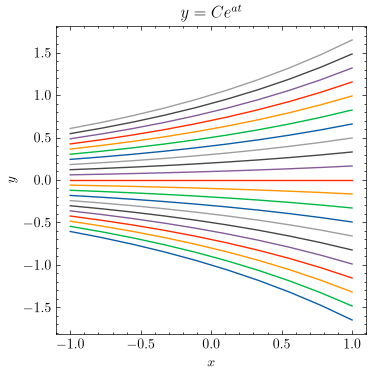

In [6]:
fig, axes = plt.subplots(figsize=(4,4))
for j in range(m):
    plt.plot(t, y[:, j])
plt.title(r"$y=C e^{at}$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.show()

## Mathematics

**Clairaut's eqaution** $y(x) = x \frac{dy}{dx} + f(\frac{dy}{dx})$

$f$ is continuously differentiable. The solution is $y(x) = Cx + f(C)$

The singular solution is
    $$\begin{array}{rr}x(t) = -f'(t)\\y(t) = f(t) - tf'(t)\end{array}$$

In [7]:
def clairaut(x, f, c):
    return c * x + f(c)

In [8]:
def clairaut_singular(t, f, df):
    return np.array([-df(ts) for ts in t]), np.array([f(ts) - ts*df(ts) for ts in t])

In [9]:
def plot_clairaut(f, df, xbegin, xend, n, csbegin, csend, tbegin, tend, title):
    fig, axes = plt.subplots(figsize = (4, 4))
    x = np.linspace(xbegin, xend, n)
    cs = np.linspace(csbegin,csend,20)
    for c in cs:
        y = clairaut(x, f, c)
        plt.plot(x, y, color = "grey")
    xt, yt = clairaut_singular(np.linspace(tbegin,tend,100),f, df)
    plt.plot(xt, yt, color = "red", label = "singular solution")
    plt.legend()
    plt.title(title)
    plt.show()

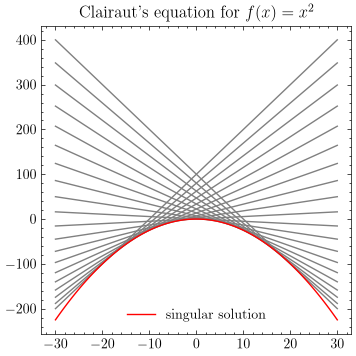

In [10]:
plot_clairaut(lambda x : x*x, lambda x : 2*x, -30, 30, 100, -10, 10, -15, 15, "Clairaut's equation for $f(x)=x^2$")

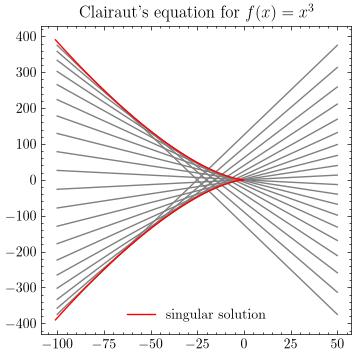

In [11]:
plot_clairaut(lambda x : x**3, lambda x : 3.0*x*x, -100, 50, 100, -5, 5, -5.8, 5.8,"Clairaut's equation for $f(x)=x^3$")